In [1]:
from matplotlib import pyplot as plt
from itertools import product
# import seaborn as sns
import pandas as pd
import os.path as op
import argparse
import re
import numpy as np
import matplotlib.pyplot as plt
import mne
import seaborn as sns
from scipy import signal
from scipy.fft import fftshift
from bids import BIDSLayout
from statsmodels.stats.anova import AnovaRM

from util.io.ffr import *

In [2]:
def read_epochs(sub, desc):
    '''
    reads and concatenates epochs across runs
    '''
    from bids import BIDSLayout
    layout = BIDSLayout(BIDS_ROOT, derivatives = True)
    run = lambda f: int(re.findall('run-(\w+)_', f)[0])
    fnames = layout.get(
        return_type = 'filename',
        subject = sub, 
        desc = desc
        )
    print(fnames)
    fnames.sort(key = run)
    epochs_all = [mne.read_epochs(f) for f in fnames]
    for epochs in epochs_all:
        print(epochs.info['sfreq'])
    epochs = mne.concatenate_epochs(epochs_all)
    epochs = epochs.pick('eeg')
    return epochs

[1, 2, 3, 5, 7, 13, 14, 16, 17, 18, 21, 23, 24, 27, 28, 32, 33, 34, 37, 40, 42, 44]
[4, 6, 8, 10, 11, 12, 15, 19, 20, 22, 25, 26, 29, 30, 31, 35, 36, 38, 39, 41, 43, 45]


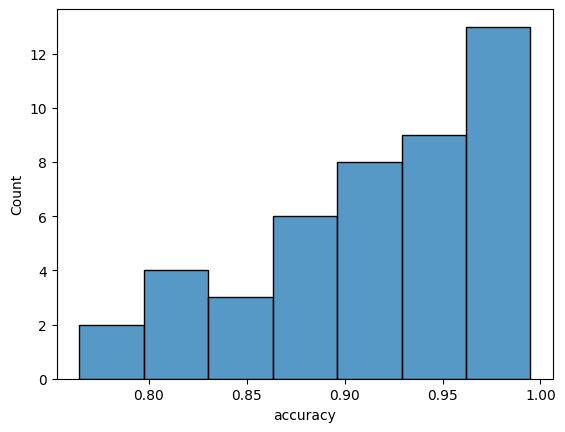

In [3]:
### Load accuracies to add to data
accuracy = pd.read_csv('accuracy.csv', index_col = 0)
sns.histplot(accuracy.accuracy)
med = np.median(accuracy.accuracy)
low_subs = list(accuracy.subject[accuracy.accuracy < med])
high_subs = list(accuracy.subject[accuracy.accuracy > med])
print(low_subs)
print(high_subs)

In [2]:
# BIDS_ROOT = '../data/bids'
# layout = BIDSLayout(BIDS_ROOT, derivatives = True, regex_search = 'forERP')
# subs = layout.get_subjects(scope = 'erp')
# subs.sort(key = int)
# evokeds = pd.DataFrame()

# for sub in subs:
    
#     # Read epochs
#     epochs = read_epochs(sub, 'forERP')
    
#     # Compute evokeds 
#     conditions = list(epochs.event_id.keys())
#     chans = ['Cz', 'Fz', 'FCz', 'CPz', 'Pz']
#     for c in conditions:
#         target = c[0]
#         tone = c[1]
#         for chan in chans:
#             uV = np.squeeze(epochs[c].average(picks = chan).get_data())
#             t = np.arange(-273, 527)

#             if int(sub) in high_subs:
#                 accuracy = 'high'
#             elif int(sub) in low_subs:
#                 accuracy = 'low'
#             # else:
#             #     accuracy = 'none'

#             d = {
#                 'sub': sub,
#                 'chan': chan,
#                 'target': target,
#                 'accuracy': accuracy,
#                 'tone': tone,
#                 'msec': t,
#                 'uV': uV
#             }

#             # Bind into dataframe
#             evoked = pd.DataFrame(d)
#             evokeds = pd.concat([evokeds, evoked])
#             evokeds = evokeds.reset_index(drop = True)
#     #         break
#     #     break
#     # break

# # Adjust units
# evokeds['uV'] = evokeds['uV'] * 1000000
# evokeds

# evokeds.to_csv('evokeds.csv', index = False) 

evokeds = pd.read_csv('evokeds.csv')

In [5]:
len(np.unique(evokeds['sub']))

39

In [5]:
# Adjust EEG timing according to lag
evokeds['msec'] = evokeds['msec'] - 27

### By tone

In [6]:
evokeds_tone_1 = evokeds[evokeds.tone == 1]
evokeds_tone_2 = evokeds[evokeds.tone == 2]
evokeds_tone_3 = evokeds[evokeds.tone == 3]

Text(0.5, 1.0, 'Tone 1')

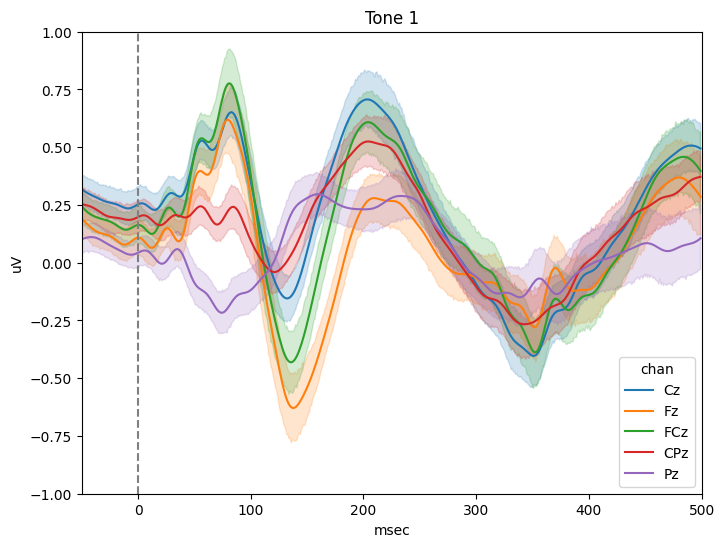

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
graph = sns.lineplot(data = evokeds_tone_1, x = "msec", y = "uV", hue = "chan", palette = 'tab10', ax = ax)
graph.axvline(0, linestyle = 'dashed', color = 'gray')
graph.set_ylabel("uV")
graph.set_xlabel("msec")
graph.set_xlim(-50, 500)
graph.set_ylim(-1, 1)
graph.set_title("Tone 1")

## By target

In [7]:
evokeds_tone_1 = evokeds_tone_1[evokeds_tone_1.chan == 'Cz']
evokeds_tone_2 = evokeds_tone_2[evokeds_tone_2.chan == 'Cz']
evokeds_tone_3 = evokeds_tone_3[evokeds_tone_3.chan == 'Cz']

/home/letitiayhho/ipykernel_4105603/314204716.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.axes.xaxis.set_ticklabels(['', '', 100, 200, 300, 400, 500])


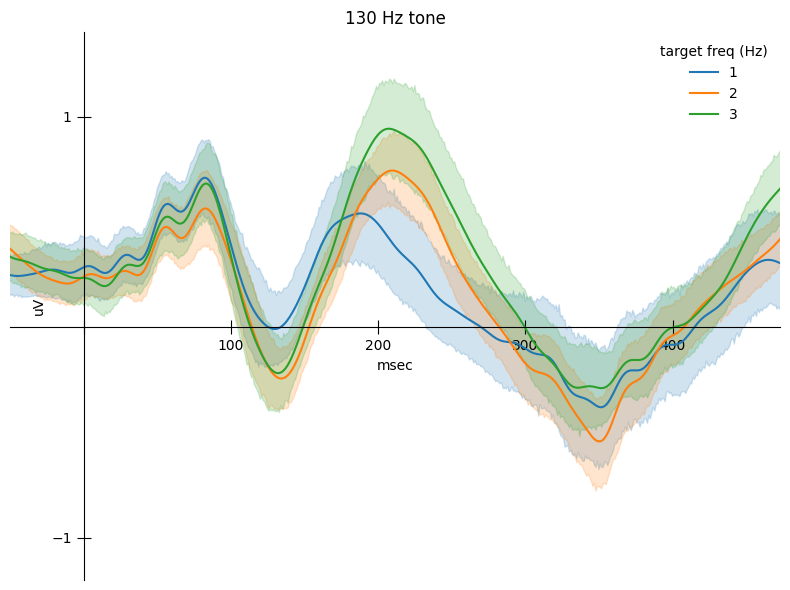

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

# Formatting
sns.despine(top=True, right=True)
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.set_yticks([-1, 1])
ax.tick_params(length = 10, direction = 'inout')
ax.axes.xaxis.set_ticklabels(['', '', 100, 200, 300, 400, 500])

# Plot
graph = sns.lineplot(data = evokeds_tone_1, x = "msec", y = "uV", hue = "target", palette = 'tab10', ax = ax)
graph.set_ylabel("uV")
graph.set_xlabel("msec")
graph.set_xlim(-50, 473)
graph.set_ylim(-1.2, 1.4)
graph.set_title("130 Hz")
plt.legend(frameon=False, title = 'target freq (Hz)', loc = 'upper right')
plt.tight_layout()
plt.savefig('../figs/ERP-tone-1-by-target.png', dpi = 300)

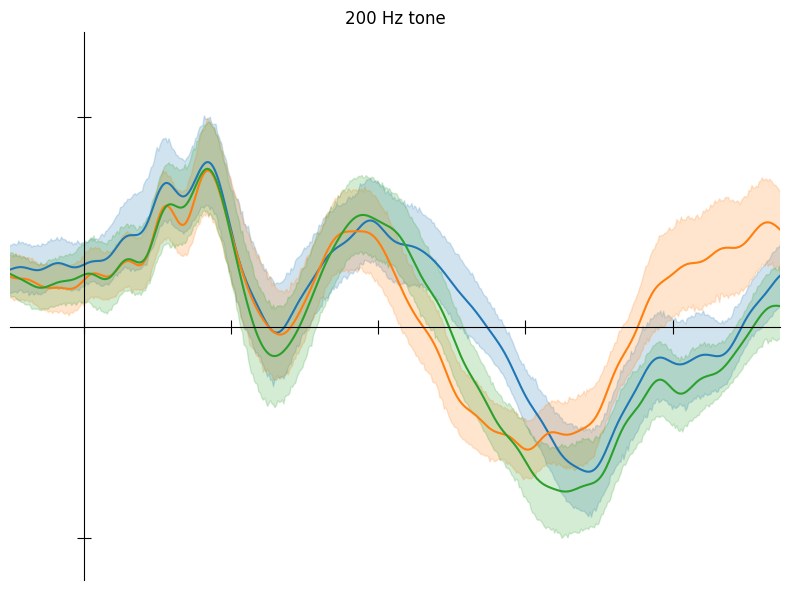

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

# Formatting
sns.despine(top=True, right=True)
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.tick_params(length = 10, direction = 'inout')
ax.set_yticks([-1, 1])
ax.axes.yaxis.set_ticklabels([])
ax.axes.xaxis.set_ticklabels([])

# Content
graph = sns.lineplot(data = evokeds_tone_2, x = "msec", y = "uV", hue = "target", palette = 'tab10', ax = ax, legend = False)
graph.set_ylabel(None)
graph.set_xlabel(None)
graph.set_xlim(-50, 473)
graph.set_ylim(-1.2, 1.4)
graph.set_title("200 Hz")
plt.tight_layout()
plt.savefig('../figs/ERP-tone-2-by-target.png', dpi = 300)

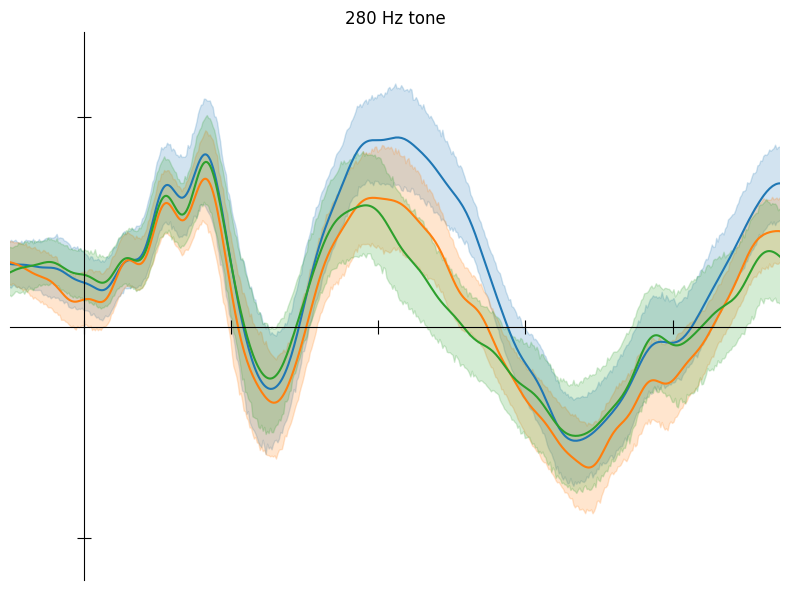

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

# Formatting
sns.despine(top=True, right=True)
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.tick_params(length = 10, direction = 'inout')
ax.set_yticks([-1, 1])
ax.axes.yaxis.set_ticklabels([])
ax.axes.xaxis.set_ticklabels([])

# Content
graph = sns.lineplot(data = evokeds_tone_3, x = "msec", y = "uV", hue = "target", palette = 'tab10', ax = ax, legend = False)
graph.set_ylabel(None)
graph.set_xlabel(None)
graph.set_xlim(-50, 473)
graph.set_ylim(-1.2, 1.4)
graph.set_title("280 Hz")
plt.tight_layout()
plt.savefig('../figs/ERP-tone-3-by-target.png', dpi = 300)

## By accuracy

In [8]:
# fig, ax = plt.subplots(figsize=(8, 6))

# # Formatting
# sns.despine(top=True, right=True)
# ax.spines['left'].set_position('zero')
# ax.spines['bottom'].set_position('zero')
# ax.set_yticks([-1, 1])
# ax.tick_params(length = 10, direction = 'inout')
# ax.axes.yaxis.set_ticklabels([])
# ax.axes.xaxis.set_ticklabels([])

# # Plot
# graph = sns.lineplot(data = evokeds_tone_1, x = 0, y = "msec", hue = "target", style = "accuracy", palette = 'tab10', ax = ax, style_order = ['high', 'low'])
# graph.set_ylabel(None)
# graph.set_xlabel(None)
# # graph.set_xlim(-50, 473)
# # graph.set_ylim(-1.2, 1.4)
# graph.set_title("130 Hz")
# plt.legend(frameon=False, loc = 'upper left')
# plt.tight_layout()
# plt.savefig('../figs/ERP-accuracy-legend.png', dpi = 300)

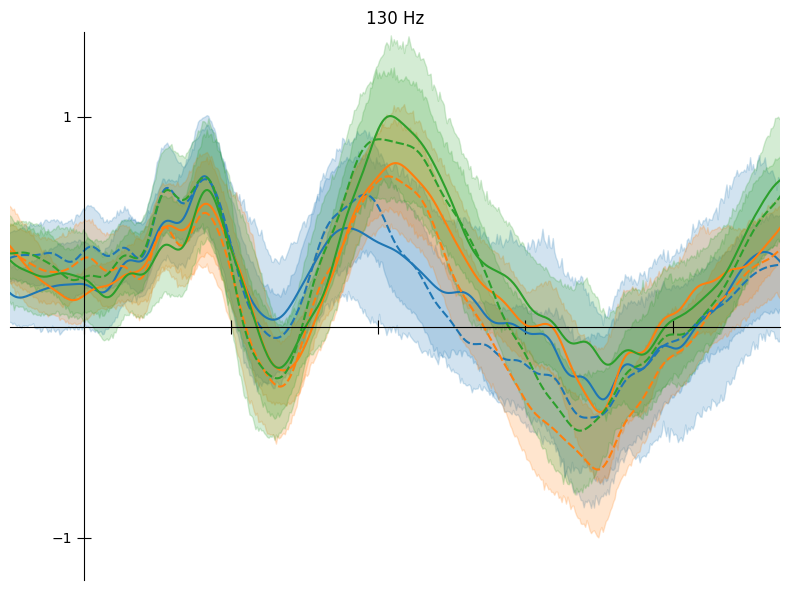

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))

# Formatting
sns.despine(top=True, right=True)
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.set_yticks([-1, 1])
ax.tick_params(length = 10, direction = 'inout')
# ax.axes.yaxis.set_ticklabels([])
ax.axes.xaxis.set_ticklabels([])

# Plot
graph = sns.lineplot(data = evokeds_tone_1, x = "msec", y = "uV", hue = "target", style = "accuracy", palette = 'tab10', ax = ax, legend = False, style_order = ['high', 'low'])
graph.set_ylabel(None)
graph.set_xlabel(None)
graph.set_xlim(-50, 473)
graph.set_ylim(-1.2, 1.4)
graph.set_title("130 Hz")
plt.tight_layout()
plt.savefig('../figs/ERP-tone-1-by-accuracy.png', dpi = 300)

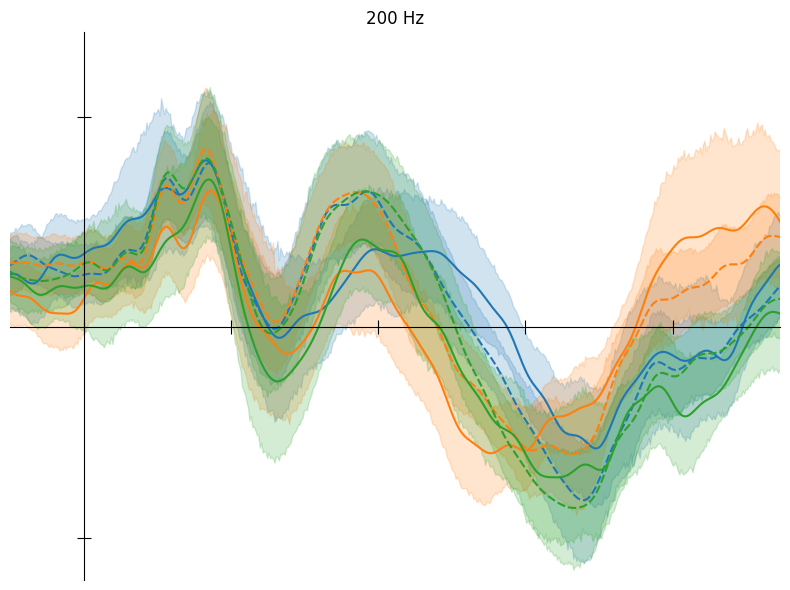

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

# Formatting
sns.despine(top=True, right=True)
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.tick_params(length = 10, direction = 'inout')
ax.set_yticks([-1, 1])
ax.axes.yaxis.set_ticklabels([])
ax.axes.xaxis.set_ticklabels([])

# Content
graph = sns.lineplot(data = evokeds_tone_2, x = "msec", y = "uV", hue = "target", style = "accuracy", palette = 'tab10', ax = ax, legend = False, style_order = ['high', 'low'])
graph.set_ylabel(None)
graph.set_xlabel(None)
graph.set_xlim(-50, 473)
graph.set_ylim(-1.2, 1.4)
graph.set_title("200 Hz")
plt.tight_layout()
plt.savefig('../figs/ERP-tone-2-by-accuracy.png', dpi = 300)

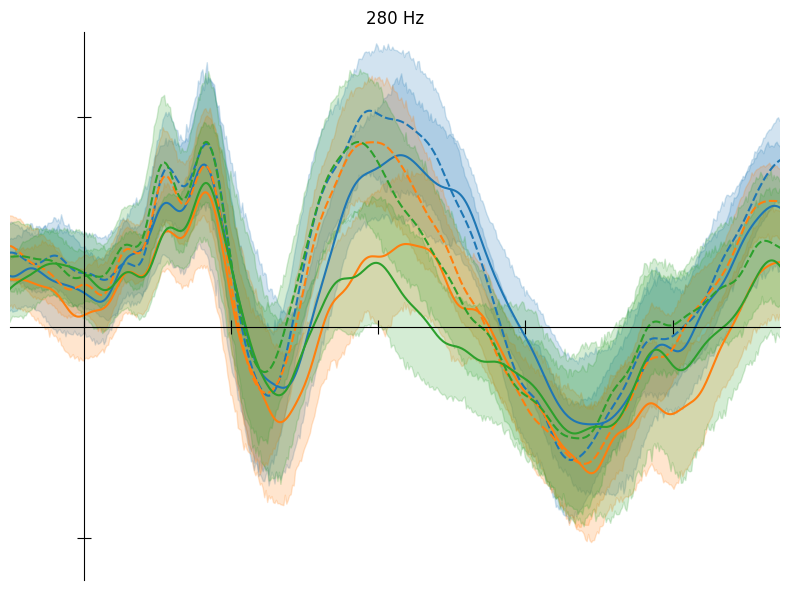

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))

# Formatting
sns.despine(top=True, right=True)
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.tick_params(length = 10, direction = 'inout')
ax.set_yticks([-1, 1])
ax.axes.yaxis.set_ticklabels([])
ax.axes.xaxis.set_ticklabels([])

# Content
graph = sns.lineplot(data = evokeds_tone_3, x = "msec", y = "uV", hue = "target", style = "accuracy", palette = 'tab10', ax = ax, legend = False, style_order = ['high', 'low'])
graph.set_ylabel(None)
graph.set_xlabel(None)
graph.set_xlim(-50, 473)
graph.set_ylim(-1.2, 1.4)
graph.set_title("280 Hz")
plt.tight_layout()
plt.savefig('../figs/ERP-tone-3-by-accuracy.png', dpi = 300)